In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("train.csv")
print(df.head())
print(df.shape)

df = df.dropna(subset=["Age"])

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [3]:
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[["Age"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.6013986013986014
                 precision    recall  f1-score   support

Did Not Survive       0.62      0.92      0.74        87
       Survived       0.46      0.11      0.17        56

       accuracy                           0.60       143
      macro avg       0.54      0.51      0.46       143
   weighted avg       0.56      0.60      0.52       143

Confusion matrix:
 [[80  7]
 [50  6]]


In [4]:
new_age = pd.DataFrame({"Age": [5, 30, 65]})
predictions = binary_model.predict(new_age)
print(predictions)
probabilities = binary_model.predict_proba(new_age)[:, 1]
for age_val, pred, prob in zip(new_age["Age"], predictions, probabilities):
    print(f"Age {age_val}: Survived = {pred}  (probability of Yes = {prob:.2f})")

[1 0 0]
Age 5: Survived = 1  (probability of Yes = 0.52)
Age 30: Survived = 0  (probability of Yes = 0.41)
Age 65: Survived = 0  (probability of Yes = 0.27)



Saved plot -> binary_logistic_plot.png


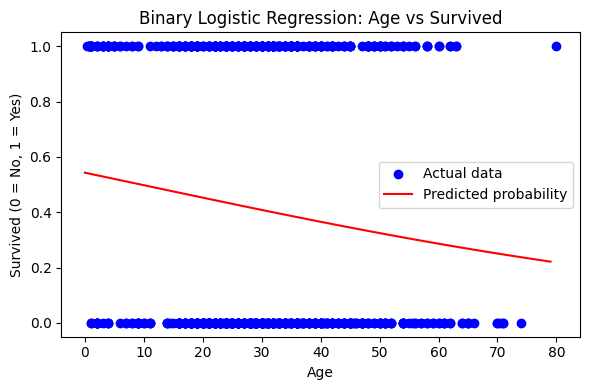

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(df["Age"], df["Survived"], color="blue", label="Actual data")
age_range = pd.DataFrame({"Age": range(0, 80)})
plt.plot(age_range["Age"], binary_model.predict_proba(age_range)[:, 1],
         color="red", label="Predicted probability")
plt.xlabel("Age")
plt.ylabel("Survived (0 = No, 1 = Yes)")
plt.title("Binary Logistic Regression: Age vs Survived")
plt.legend()
plt.tight_layout()
plt.savefig("binary_logistic_plot.png")
print("\nSaved plot -> binary_logistic_plot.png")